# Analyse exploratoire

In [104]:
### Import des modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import pairplot

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [105]:
# Import des fichiers
data_sirh = pd.read_csv('data/raw/extrait_sirh.csv', sep=',', na_values=[''], quotechar='"')
data_eval = pd.read_csv('data/raw/extrait_eval.csv', sep=',', na_values=[''], quotechar='"')
data_sondage = pd.read_csv('data/raw/extrait_sondage.csv', sep=',', na_values=[''], quotechar='"')

In [106]:
# La colonne eval_number va nous servir pour la jointure des fichiers E_employee_id
data_eval['id_employee'] = data_eval['eval_number'].apply(lambda x : x.split('E_')[1])
data_eval['id_employee'] = data_eval['id_employee'].astype(int)
data_eval.drop(columns=['eval_number'], inplace=True)

# On renomme juste la colonne code_sonadage qui contient l'employee_id
data_sondage.rename(columns={'code_sondage': 'id_employee'}, inplace=True)

In [107]:
# Fusion des fichiers
data = data_sirh.merge(data_eval, how='inner')
data = data.merge(data_sondage, how='inner')

In [108]:
import os

if not os.path.exists('./data/interim/'):
    os.mkdir('./data/interim/')

data.to_csv('./data/interim/employees.csv', index=False)

In [109]:
data.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'], dtype='str')

In [110]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   genre                                      1470 non-null   str  
 3   revenu_mensuel                             1470 non-null   int64
 4   statut_marital                             1470 non-null   str  
 5   departement                                1470 non-null   str  
 6   poste                                      1470 non-null   str  
 7   nombre_experiences_precedentes             1470 non-null   int64
 8   nombre_heures_travailless                  1470 non-null   int64
 9   annee_experience_totale                    1470 non-null   int64
 10  annees_dans_l_entreprise                   1470 non-null   

In [111]:
data.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [112]:
# Nombre d'employés total
nb_total_employee = data.shape[0]
current_employees = data[data['a_quitte_l_entreprise'] == 'Non']
resigned_employees = data[data['a_quitte_l_entreprise'] == 'Oui']

print(f'Nombre de employees: {nb_total_employee}')
print(f'Nombre de employees ayant démissionné: {resigned_employees.shape[0]}')
print(f'Nombre de restant: {current_employees.shape[0]}')
print(f'Soit un turnover de {100 * resigned_employees.shape[0] / nb_total_employee:.2f}%')

Nombre de employees: 1470
Nombre de employees ayant démissionné: 237
Nombre de restant: 1233
Soit un turnover de 16.12%


Text(0.5, 0, 'Age')

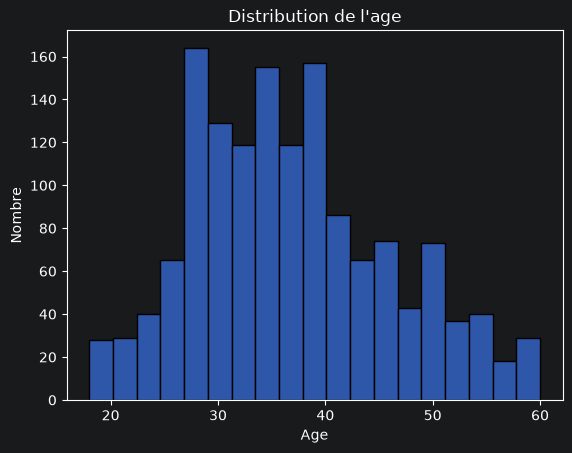

In [113]:
sns.histplot(data['age'])
plt.title('Distribution de l\'age')
plt.ylabel('Nombre')
plt.xlabel("Age")

Text(0.5, 0, 'Salaire')

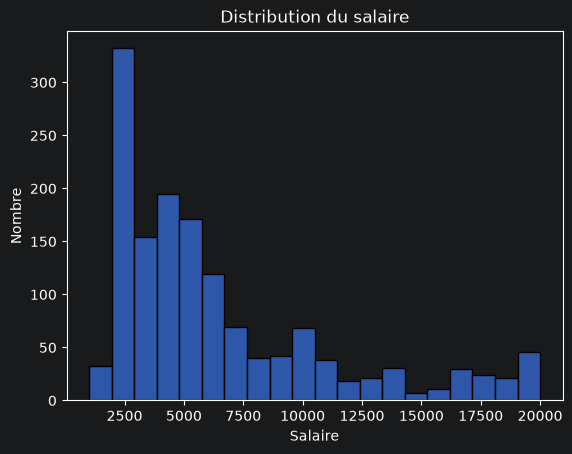

In [114]:
sns.histplot(data['revenu_mensuel'])
plt.title('Distribution du salaire')
plt.ylabel('Nombre')
plt.xlabel("Salaire")

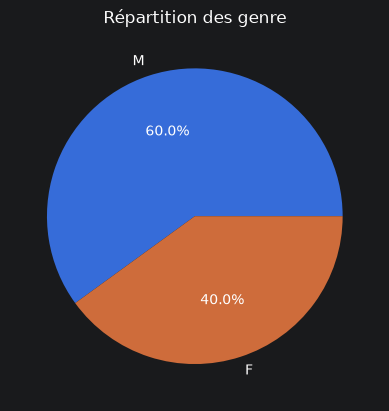

In [115]:
counts = data['genre'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Répartition des genre')
plt.show()

Text(0.5, 0, 'Genre')

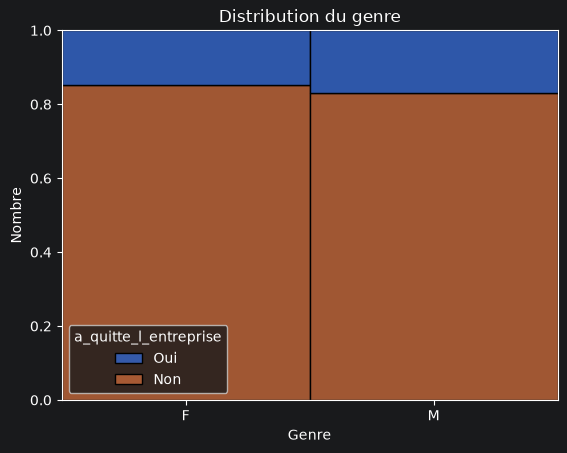

In [116]:
sns.histplot(data, x='genre', hue='a_quitte_l_entreprise', multiple='fill')
plt.title('Distribution du genre')
plt.ylabel('Nombre')
plt.xlabel("Genre")

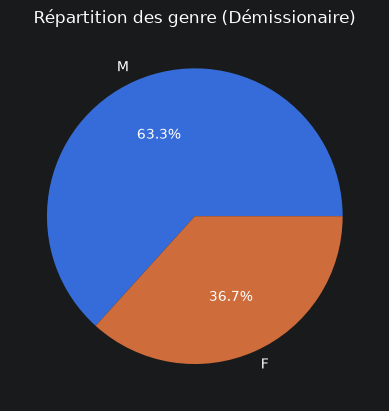

In [117]:
counts = resigned_employees['genre'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Répartition des genre (Démissionaire)')
plt.show()

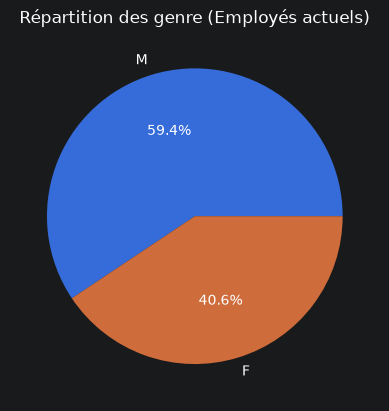

In [118]:
counts = current_employees['genre'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Répartition des genre (Employés actuels)')
plt.show()

Text(0.5, 0, 'Age')

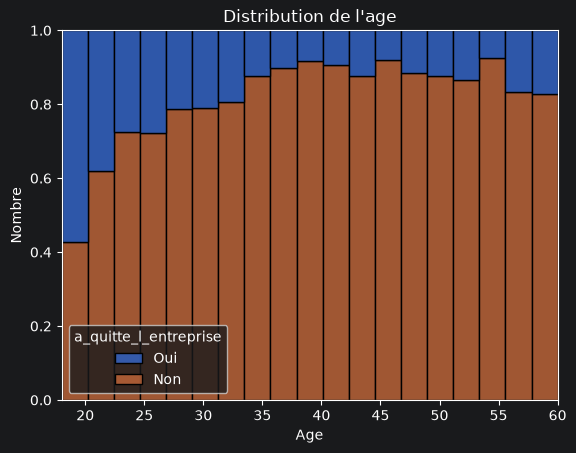

In [119]:
sns.histplot(data, x='age', hue='a_quitte_l_entreprise', multiple='fill')
plt.title('Distribution de l\'age')
plt.ylabel('Nombre')
plt.xlabel("Age")

In [120]:
current_employees['age'].describe()

count    1233.000000
mean       37.561233
std         8.888360
min        18.000000
25%        31.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: age, dtype: float64

In [121]:
resigned_employees['age'].describe()

count    237.000000
mean      33.607595
std        9.689350
min       18.000000
25%       28.000000
50%       32.000000
75%       39.000000
max       58.000000
Name: age, dtype: float64

In [122]:
resigned_employees['annees_dans_l_entreprise'].describe()

count    237.000000
mean       5.130802
std        5.949984
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       40.000000
Name: annees_dans_l_entreprise, dtype: float64

In [123]:
current_employees['annees_dans_l_entreprise'].describe()

count    1233.000000
mean        7.369019
std         6.096298
min         0.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        37.000000
Name: annees_dans_l_entreprise, dtype: float64

<Axes: xlabel='annees_dans_l_entreprise', ylabel='Count'>

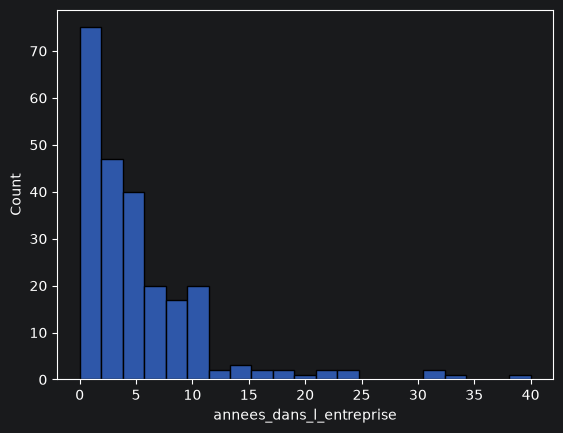

In [124]:
sns.histplot(resigned_employees, x='annees_dans_l_entreprise')

<Axes: xlabel='age', ylabel='revenu_mensuel'>

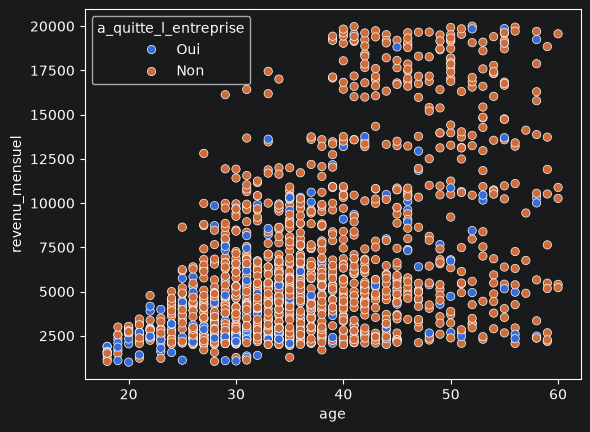

In [125]:
sns.scatterplot(x=data['age'], y=data['revenu_mensuel'], hue=data['a_quitte_l_entreprise'])

<Axes: xlabel='annees_dans_l_entreprise', ylabel='revenu_mensuel'>

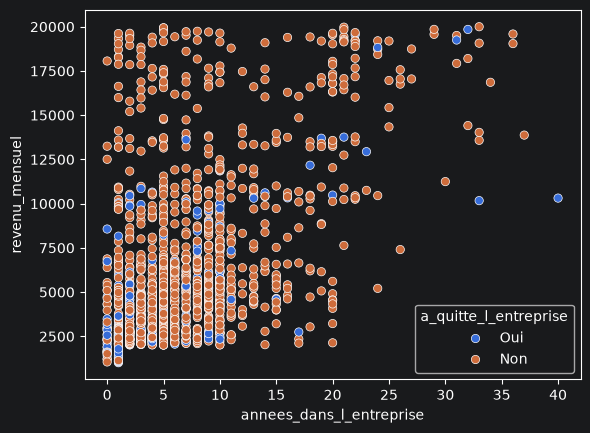

In [126]:
sns.scatterplot(x=data['annees_dans_l_entreprise'], y=data['revenu_mensuel'], hue=data['a_quitte_l_entreprise'])

<Axes: xlabel='annee_experience_totale', ylabel='revenu_mensuel'>

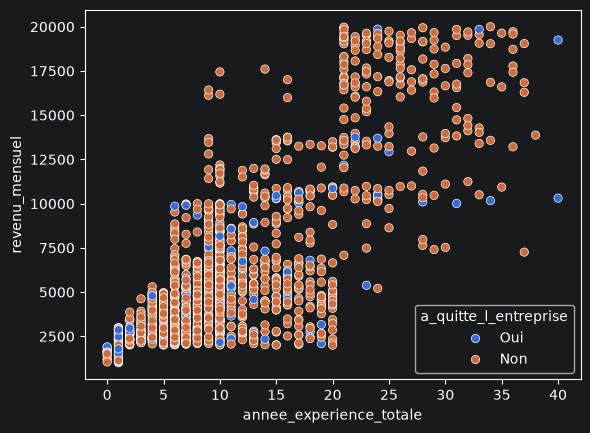

In [127]:
sns.scatterplot(x=data['annee_experience_totale'], y=data['revenu_mensuel'], hue=data['a_quitte_l_entreprise'])

In [128]:
data['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [129]:
data[data['genre'] == 'M']['revenu_mensuel'].describe()

count      882.000000
mean      6380.507937
std       4714.856577
min       1009.000000
25%       2819.500000
50%       4837.500000
75%       8113.750000
max      19999.000000
Name: revenu_mensuel, dtype: float64

In [130]:
data[data['genre'] == 'F']['revenu_mensuel'].describe()

count      588.000000
mean      6686.566327
std       4695.608507
min       1129.000000
25%       3037.000000
50%       5081.500000
75%       8711.750000
max      19973.000000
Name: revenu_mensuel, dtype: float64

In [131]:
current_employees['genre'].value_counts()

genre
M    732
F    501
Name: count, dtype: int64

In [132]:
resigned_employees['genre'].value_counts()

genre
M    150
F     87
Name: count, dtype: int64

In [133]:
resigned_employees['annees_depuis_la_derniere_promotion'].describe()

count    237.000000
mean       1.945148
std        3.153077
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max       15.000000
Name: annees_depuis_la_derniere_promotion, dtype: float64

In [134]:
current_employees['annees_depuis_la_derniere_promotion'].describe()

count    1233.000000
mean        2.234388
std         3.234762
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        15.000000
Name: annees_depuis_la_derniere_promotion, dtype: float64

In [135]:
resigned_employees['annees_dans_le_poste_actuel'].describe()

count    237.000000
mean       2.902954
std        3.174827
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: annees_dans_le_poste_actuel, dtype: float64

In [136]:
current_employees['annees_dans_le_poste_actuel'].describe()

count    1233.000000
mean        4.484185
std         3.649402
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        18.000000
Name: annees_dans_le_poste_actuel, dtype: float64

In [137]:
resigned_employees['revenu_mensuel'].describe()

count      237.000000
mean      4787.092827
std       3640.210367
min       1009.000000
25%       2373.000000
50%       3202.000000
75%       5916.000000
max      19859.000000
Name: revenu_mensuel, dtype: float64

In [138]:
current_employees['revenu_mensuel'].describe()

count     1233.000000
mean      6832.739659
std       4818.208001
min       1051.000000
25%       3211.000000
50%       5204.000000
75%       8834.000000
max      19999.000000
Name: revenu_mensuel, dtype: float64

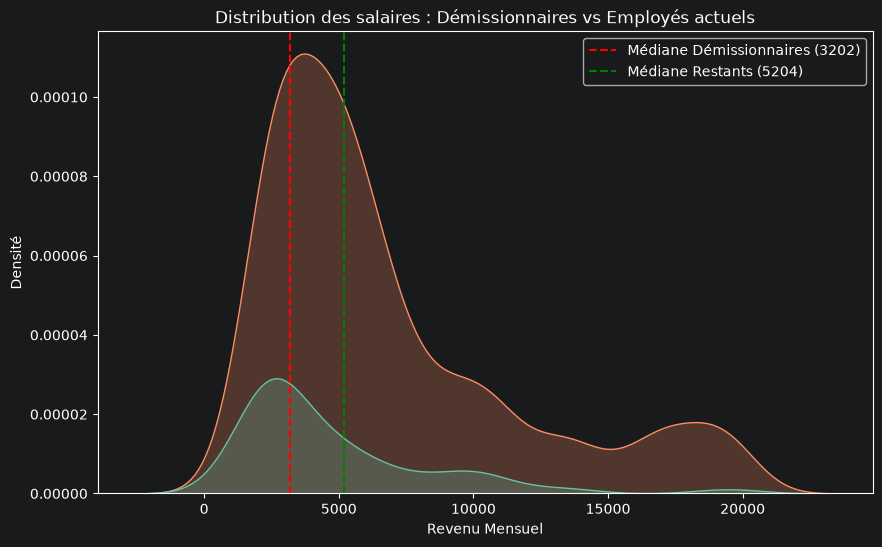

In [139]:
plt.figure(figsize=(10, 6))

# Le paramètre common_norm=False permet de comparer les proportions équitablement
# malgré le fait qu'il y ait beaucoup moins de démissionnaires au total.
sns.kdeplot(
    data=data,
    x='revenu_mensuel',
    hue='a_quitte_l_entreprise',
    fill=True,
    palette='Set2'
)

plt.title("Distribution des salaires : Démissionnaires vs Employés actuels")
plt.xlabel("Revenu Mensuel")
plt.ylabel("Densité")
plt.axvline(3202, color='red', linestyle='--', label='Médiane Démissionnaires (3202)')
plt.axvline(5204, color='green', linestyle='--', label='Médiane Restants (5204)')
plt.legend()
plt.show()

In [140]:
delta = resigned_employees['note_evaluation_actuelle'].mean() - resigned_employees['note_evaluation_precedente'].mean()
delta.mean()

np.float64(0.6371308016877637)

In [141]:
resigned_employees['note_evaluation_actuelle'].describe()

count    237.000000
mean       3.156118
std        0.363735
min        3.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: note_evaluation_actuelle, dtype: float64

In [142]:
delta = current_employees['note_evaluation_actuelle'].mean() - current_employees['note_evaluation_precedente'].mean()
delta.mean()

np.float64(0.38280616382806176)

In [143]:
data['distance_domicile_travail'].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: distance_domicile_travail, dtype: float64

In [144]:
current_employees['distance_domicile_travail'].describe()

count    1233.000000
mean        8.915653
std         8.012633
min         1.000000
25%         2.000000
50%         7.000000
75%        13.000000
max        29.000000
Name: distance_domicile_travail, dtype: float64

In [145]:
resigned_employees['distance_domicile_travail'].describe()

count    237.000000
mean      10.632911
std        8.452525
min        1.000000
25%        3.000000
50%        9.000000
75%       17.000000
max       29.000000
Name: distance_domicile_travail, dtype: float64

In [146]:
resigned_employees['frequence_deplacement'].value_counts(normalize=True) * 100

frequence_deplacement
Occasionnel    65.822785
Frequent       29.113924
Aucun           5.063291
Name: proportion, dtype: float64

In [147]:
current_employees['frequence_deplacement'].value_counts(normalize=True) * 100

frequence_deplacement
Occasionnel    71.938362
Frequent       16.869424
Aucun          11.192214
Name: proportion, dtype: float64

Text(0, 0.5, 'Proportion')

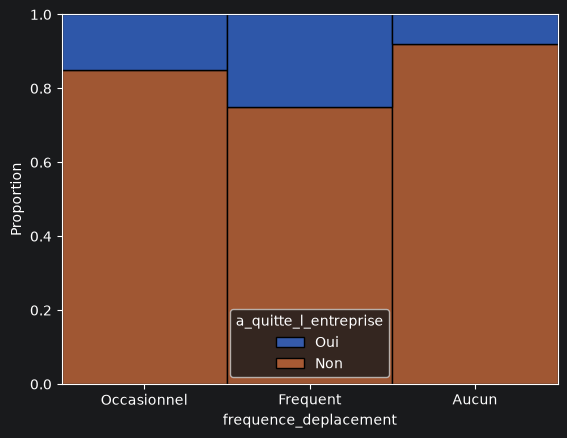

In [148]:
sns.histplot(data, x='frequence_deplacement', hue='a_quitte_l_entreprise', multiple='fill')
plt.ylabel("Proportion")

In [149]:
current_employees['heure_supplementaires'].value_counts(normalize=True) * 100

heure_supplementaires
Non    76.561233
Oui    23.438767
Name: proportion, dtype: float64

Text(0.5, 0, 'Heures supplémentaires')

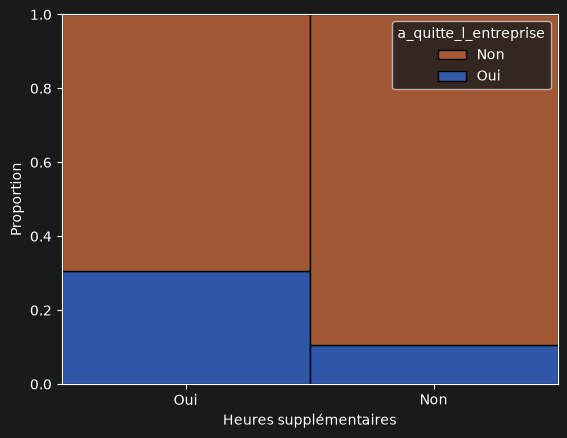

In [244]:
sns.histplot(data, x='heure_supplementaires', hue='a_quitte_l_entreprise', multiple='fill', hue_order=['Non', 'Oui'],
    palette={'Non': 'C1', 'Oui': 'C0'})
plt.ylabel('Proportion')
plt.xlabel('Heures supplémentaires')

In [151]:
resigned_employees['heure_supplementaires'].value_counts(normalize=True) * 100

heure_supplementaires
Oui    53.586498
Non    46.413502
Name: proportion, dtype: float64

In [152]:
resigned_employees['satisfaction_employee_equilibre_pro_perso'].describe()

count    237.000000
mean       2.658228
std        0.816453
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: satisfaction_employee_equilibre_pro_perso, dtype: float64

In [153]:
current_employees['satisfaction_employee_equilibre_pro_perso'].describe()

count    1233.000000
mean        2.781022
std         0.681907
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: satisfaction_employee_equilibre_pro_perso, dtype: float64

In [154]:
resigned_employees['poste'].value_counts()

poste
Consultant                 62
Cadre Commercial           57
Assistant de Direction     47
Représentant Commercial    33
Ressources Humaines        12
Tech Lead                  10
Manager                     9
Senior Manager              5
Directeur Technique         2
Name: count, dtype: int64

In [155]:
current_employees['satisfaction_employee_environnement'].describe()

count    1233.000000
mean        2.771290
std         1.071132
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: satisfaction_employee_environnement, dtype: float64

In [156]:
resigned_employees['satisfaction_employee_environnement'].describe()


count    237.000000
mean       2.464135
std        1.169791
min        1.000000
25%        1.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: satisfaction_employee_environnement, dtype: float64

In [195]:
data.groupby(['poste', 'genre'])['revenu_mensuel'].median()

poste                    genre
Assistant de Direction   F         2920.0
                         M         2856.0
Cadre Commercial         F         5966.5
                         M         6386.0
Consultant               F         2926.0
                         M         2842.5
Directeur Technique      F        14275.0
                         M        17584.0
Manager                  F         6812.0
                         M         6768.0
Représentant Commercial  F         2617.0
                         M         2476.0
Ressources Humaines      F         3068.5
                         M         3265.0
Senior Manager           F        17123.0
                         M        17861.0
Tech Lead                F         6460.5
                         M         6434.0
Name: revenu_mensuel, dtype: float64

In [158]:
current_employees.groupby(['poste', 'genre'])['revenu_mensuel'].mean()

poste                    genre
Assistant de Direction   F         3445.505155
                         M         3251.189189
Cadre Commercial         F         6783.178571
                         M         6819.910828
Consultant               F         3373.666667
                         M         3317.578125
Directeur Technique      F        15006.968750
                         M        16601.521739
Manager                  F         7382.130435
                         M         7496.789474
Représentant Commercial  F         2826.272727
                         M         2776.571429
Ressources Humaines      F         5002.700000
                         M         4188.100000
Senior Manager           F        16807.755556
                         M        17542.211538
Tech Lead                F         7377.441176
                         M         7201.104478
Name: revenu_mensuel, dtype: float64

In [159]:
r = resigned_employees.groupby(['poste', 'genre'])['revenu_mensuel'].agg(
    revenu_mensuel='mean',
    nombre='count'
)

print(r)

                               revenu_mensuel  nombre
poste                   genre                        
Assistant de Direction  F         2768.000000      17
                        M         2787.533333      30
Cadre Commercial        F         6658.650000      20
                        M         7937.837838      37
Consultant              F         2700.250000      16
                        M         2995.434783      46
Directeur Technique     F        19545.000000       1
                        M        19246.000000       1
Manager                 F         7909.200000       5
                        M         9347.000000       4
Représentant Commercial F         2459.750000      16
                        M         2275.294118      17
Ressources Humaines     F         3770.666667       6
                        M         3660.833333       6
Senior Manager          F        19334.500000       2
                        M        15106.000000       3
Tech Lead               F   

In [160]:
resigned_employees['nombre_participation_pee'].describe()

count    237.000000
mean       0.527426
std        0.856361
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: nombre_participation_pee, dtype: float64

In [161]:
current_employees['nombre_participation_pee'].describe()

count    1233.000000
mean        0.845093
std         0.841985
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: nombre_participation_pee, dtype: float64

In [162]:
r = resigned_employees.groupby(['poste'])['annees_dans_l_entreprise'].agg(
    annees_dans_l_entreprise='mean',
    nombre='count'
).sort_values(by='nombre')
print(r)

                         annees_dans_l_entreprise  nombre
poste                                                    
Directeur Technique                     26.500000       2
Senior Manager                          15.600000       5
Manager                                 10.888889       9
Tech Lead                                8.700000      10
Ressources Humaines                      4.166667      12
Représentant Commercial                  2.090909      33
Assistant de Direction                   4.319149      47
Cadre Commercial                         6.701754      57
Consultant                               3.161290      62


In [163]:
data['augementation_salaire_precedente_number'] = data['augementation_salaire_precedente'].apply(lambda x: x.split(' %')[0])
data['augementation_salaire_precedente_number'] = data['augementation_salaire_precedente_number'].astype('int')
cols_to_numeric = ['revenu_mensuel', 'niveau_hierarchique_poste', 'augementation_salaire_precedente_number']

resume_global = data.groupby('genre')[['revenu_mensuel', 'augementation_salaire_precedente_number']].mean()
print(resume_global)

       revenu_mensuel  augementation_salaire_precedente_number
genre                                                         
F         6686.566327                                15.197279
M         6380.507937                                15.217687


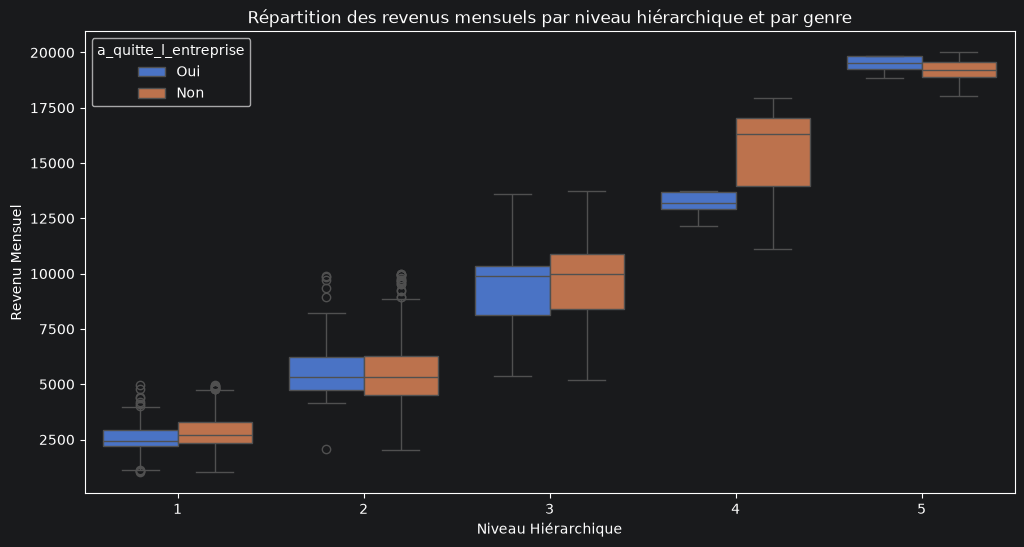

In [164]:
plt.figure(figsize=(12, 6))
# On trace le salaire en fonction du niveau hiérarchique, séparé par genre (hue)
sns.boxplot(data=data, x='niveau_hierarchique_poste', y='revenu_mensuel', hue='a_quitte_l_entreprise')

plt.title("Répartition des revenus mensuels par niveau hiérarchique et par genre")
plt.xlabel("Niveau Hiérarchique")
plt.ylabel("Revenu Mensuel")
plt.show()

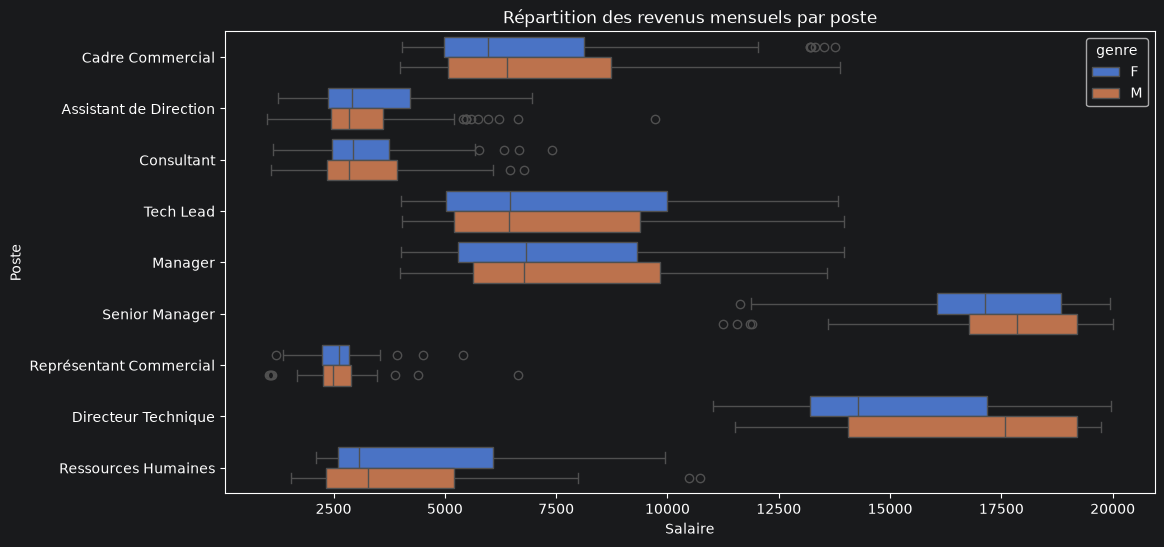

In [198]:
plt.figure(figsize=(12, 6))
# On trace le salaire en fonction du niveau hiérarchique, séparé par genre (hue)
sns.boxplot(data=data, y='poste', x='revenu_mensuel', hue='genre')

plt.title("Répartition des revenus mensuels par poste")
plt.xlabel("Salaire")
plt.ylabel("Poste")
plt.show()

Text(0, 0.5, 'Poste')

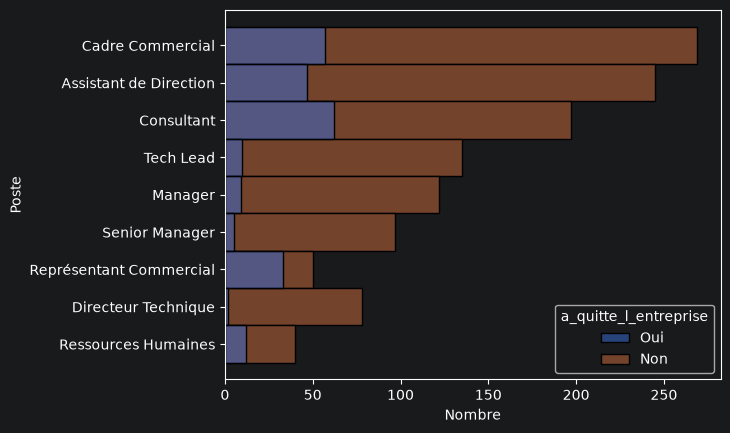

In [248]:
sns.histplot(data=data, y='poste', hue='a_quitte_l_entreprise')
plt.xlabel('Nombre')
plt.ylabel('Poste')

Text(0.5, 0, 'Nombre')

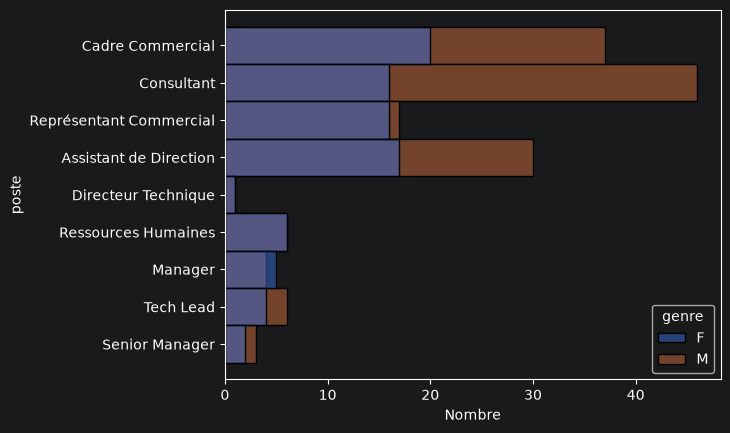

In [245]:
sns.histplot(data=resigned_employees, y='poste', hue='genre')


In [229]:
resigned_employees['frequence_deplacement'].value_counts()

frequence_deplacement
Occasionnel    156
Frequent        69
Aucun           12
Name: count, dtype: int64

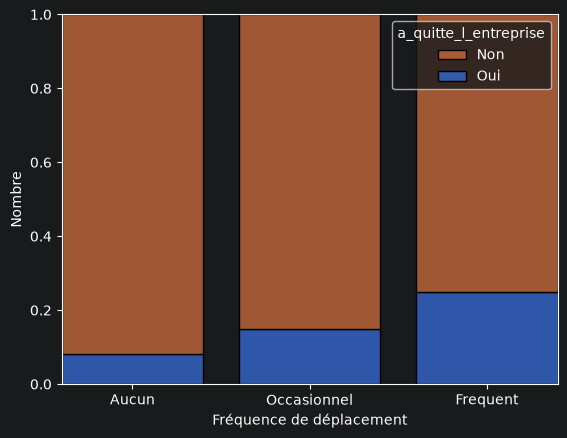

In [239]:
ordre_deplacement = ['Aucun', 'Occasionnel', 'Frequent']
data['frequence_deplacement'] = pd.Categorical(
    data['frequence_deplacement'],
    categories=ordre_deplacement,
    ordered=True
)

sns.histplot(
    data=data,
    x='frequence_deplacement',
    hue='a_quitte_l_entreprise',
    multiple='fill',
    shrink=0.8,
    hue_order=['Non', 'Oui'],
    palette={'Non': 'C1', 'Oui': 'C0'}
)

plt.xlabel("Fréquence de déplacement")
plt.ylabel("Nombre")
plt.show()


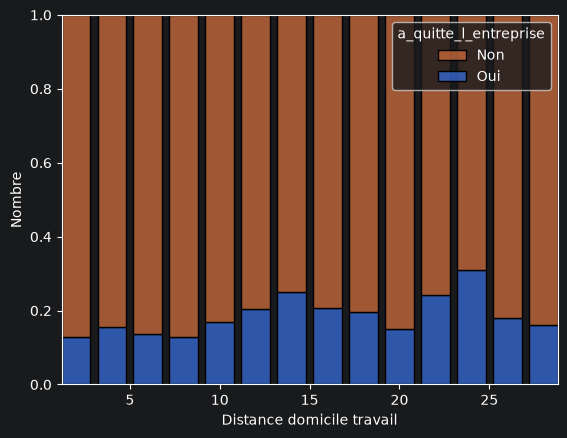

In [241]:

sns.histplot(
    data=data,
    x='distance_domicile_travail',
    hue='a_quitte_l_entreprise',
    multiple='fill',
    shrink=0.8,
    hue_order=['Non', 'Oui'],
    palette={'Non': 'C1', 'Oui': 'C0'}
)

plt.xlabel("Distance domicile travail")
plt.ylabel("Nombre")
plt.show()

In [169]:
current_employees['nb_formations_suivies'].describe()


count    1233.000000
mean        2.832928
std         1.293585
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: nb_formations_suivies, dtype: float64

In [170]:
resigned_employees['nb_formations_suivies'].describe()


count    237.000000
mean       2.624473
std        1.254784
min        0.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: nb_formations_suivies, dtype: float64

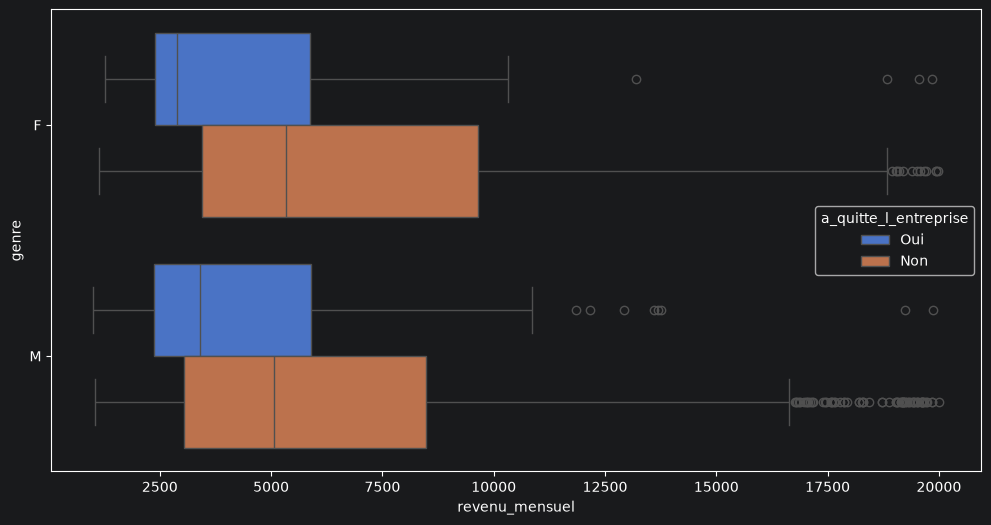

In [171]:
plt.figure(figsize=(12, 6))
# On trace le salaire en fonction du niveau hiérarchique, séparé par genre (hue)
sns.boxplot(data=data, x='revenu_mensuel', y='genre', hue='a_quitte_l_entreprise')

plt.show()

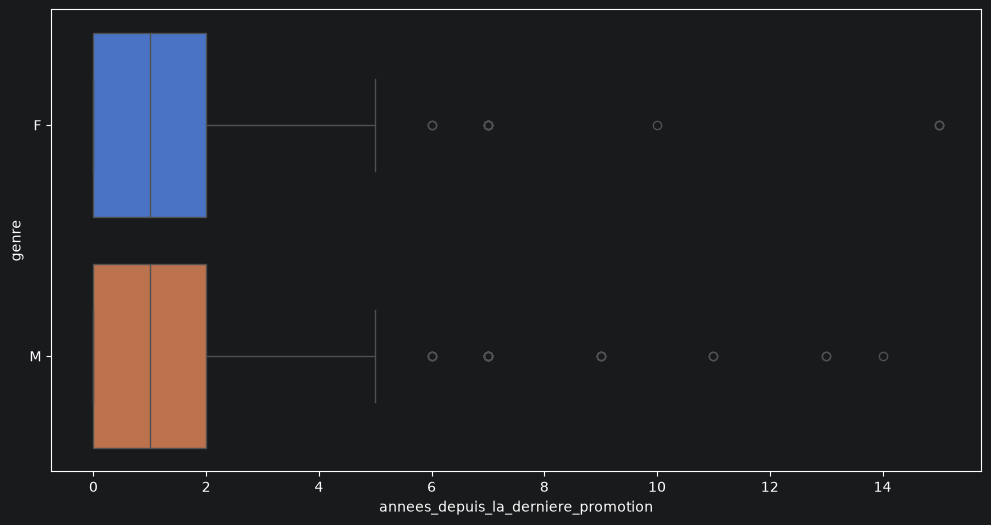

In [172]:
plt.figure(figsize=(12, 6))
# On trace le salaire en fonction du niveau hiérarchique, séparé par genre (hue)
sns.boxplot(data=resigned_employees, x='annees_depuis_la_derniere_promotion', y='genre', hue='genre')

plt.show()

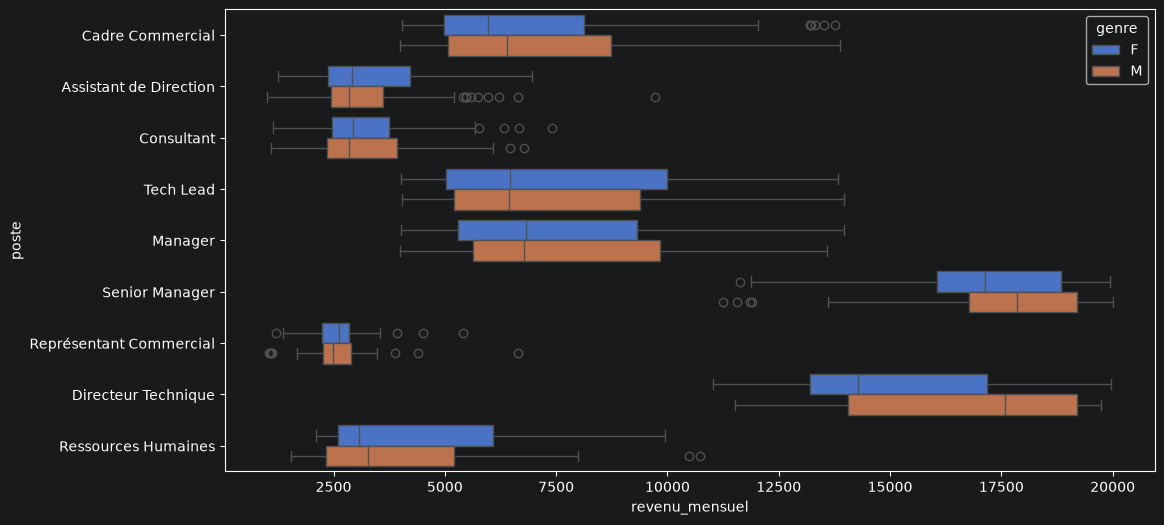

In [216]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=data, y='poste', x='revenu_mensuel', hue='genre')

plt.show()

In [174]:
satisfaction_columns = [
    'satisfaction_employee_environnement',
    'note_evaluation_precedente',
    'niveau_hierarchique_poste',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_actuelle'
]

for col in satisfaction_columns:
    score_resigned = round(resigned_employees[col].mean(), 2)
    score_current = round(current_employees[col].mean(), 2)
    delta = score_current - score_resigned
    delta_percentage = round(delta / score_current * 100, 2)
    print(f'{col} : resigned={score_resigned} vs current={score_current} soit différence de {delta_percentage}%')

satisfaction_employee_environnement : resigned=2.46 vs current=2.77 soit différence de 11.19%
note_evaluation_precedente : resigned=2.52 vs current=2.77 soit différence de 9.03%
niveau_hierarchique_poste : resigned=1.64 vs current=2.15 soit différence de 23.72%
satisfaction_employee_nature_travail : resigned=2.47 vs current=2.78 soit différence de 11.15%
satisfaction_employee_equipe : resigned=2.6 vs current=2.73 soit différence de 4.76%
satisfaction_employee_equilibre_pro_perso : resigned=2.66 vs current=2.78 soit différence de 4.32%
note_evaluation_actuelle : resigned=3.16 vs current=3.15 soit différence de -0.32%


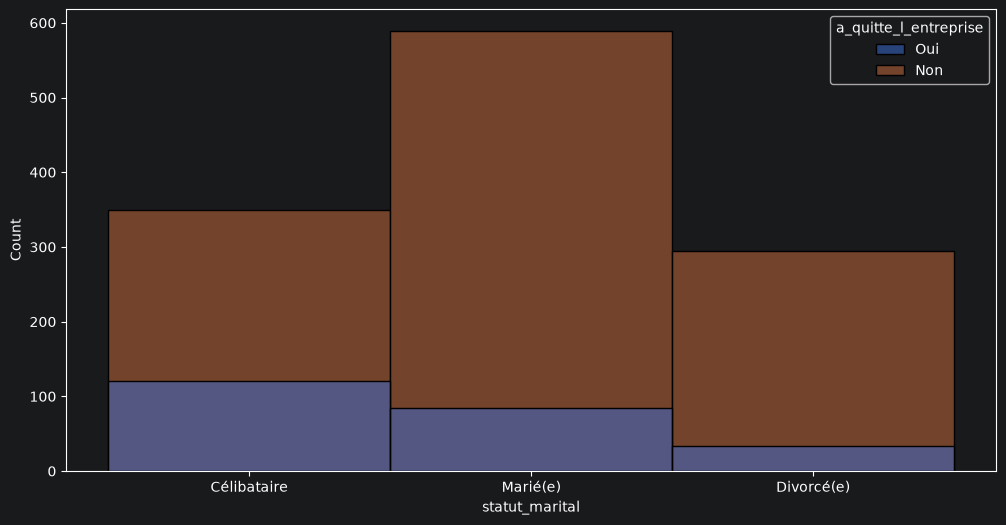

In [175]:
plt.figure(figsize=(12, 6))
# On trace le salaire en fonction du niveau hiérarchique, séparé par genre (hue)
sns.histplot(data=data, x='statut_marital', hue='a_quitte_l_entreprise')

plt.show()

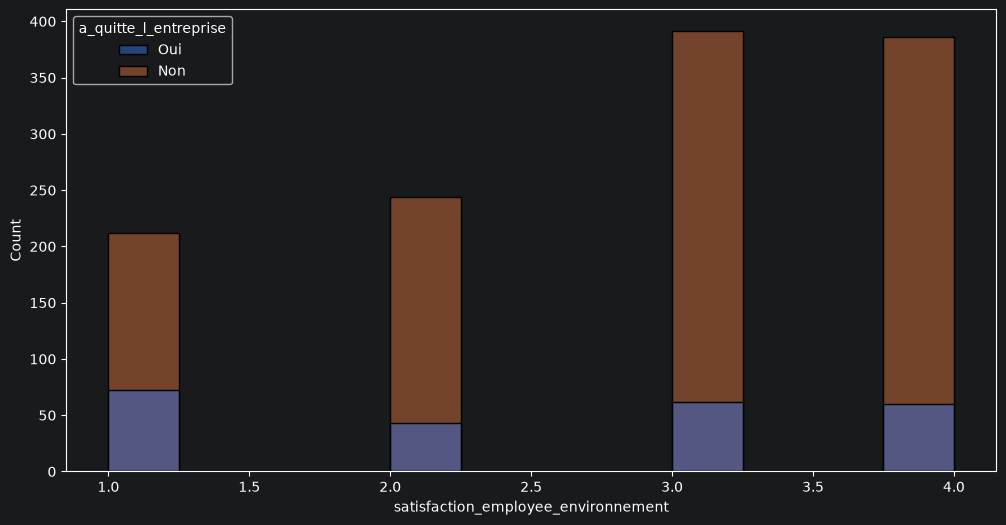

In [176]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='satisfaction_employee_environnement', hue='a_quitte_l_entreprise')
plt.show()

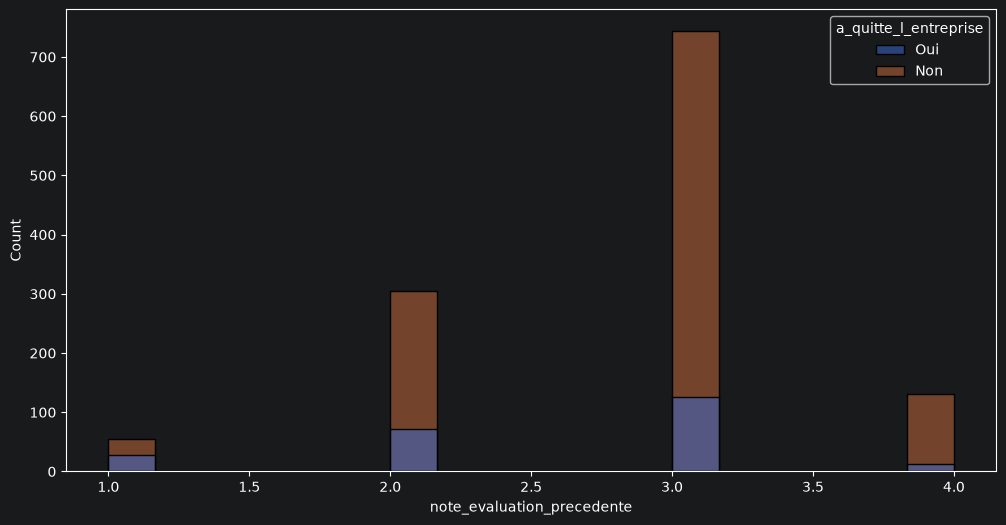

In [177]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='note_evaluation_precedente', hue='a_quitte_l_entreprise')
plt.show()

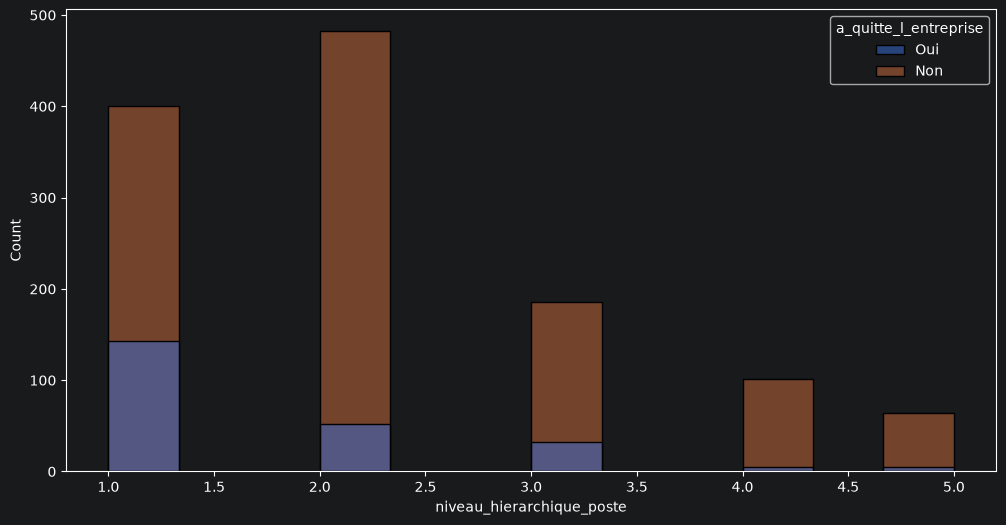

In [178]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='niveau_hierarchique_poste', hue='a_quitte_l_entreprise')
plt.show()

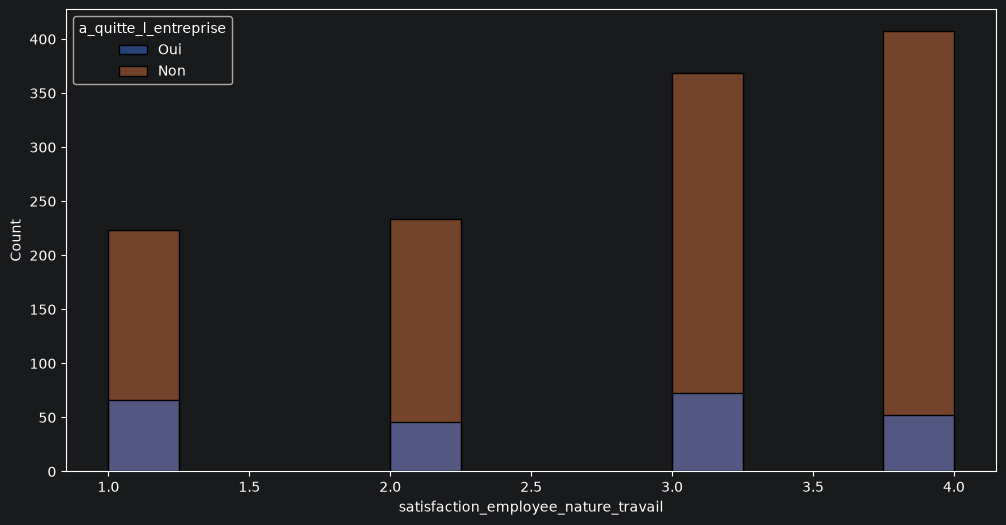

In [179]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='satisfaction_employee_nature_travail', hue='a_quitte_l_entreprise')
plt.show()

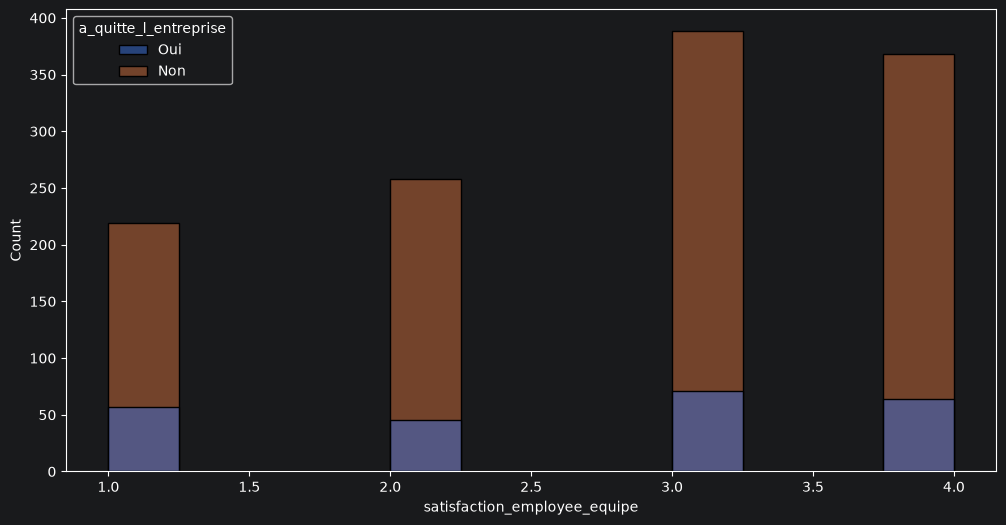

In [180]:

plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='satisfaction_employee_equipe', hue='a_quitte_l_entreprise')
plt.show()

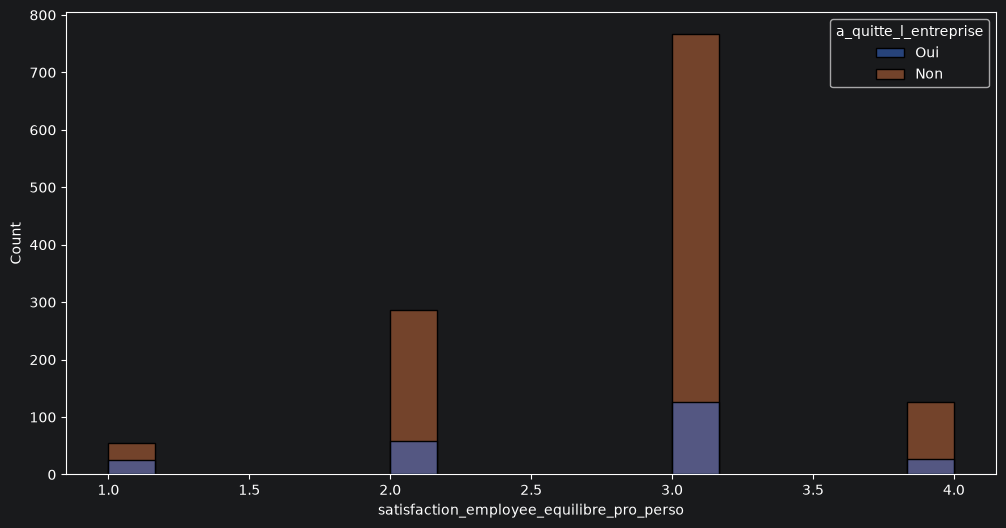

In [181]:

plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='satisfaction_employee_equilibre_pro_perso', hue='a_quitte_l_entreprise')
plt.show()

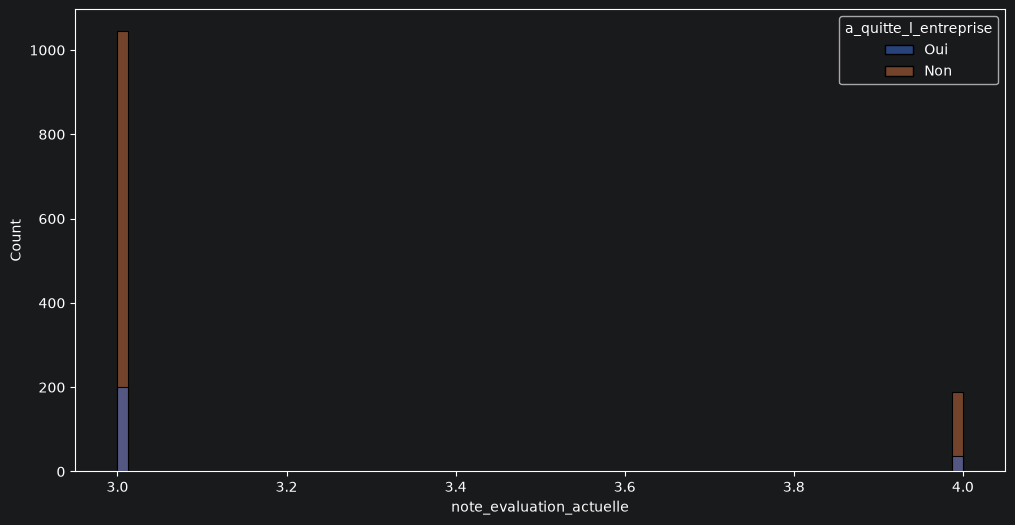

In [182]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='note_evaluation_actuelle', hue='a_quitte_l_entreprise')
plt.show()

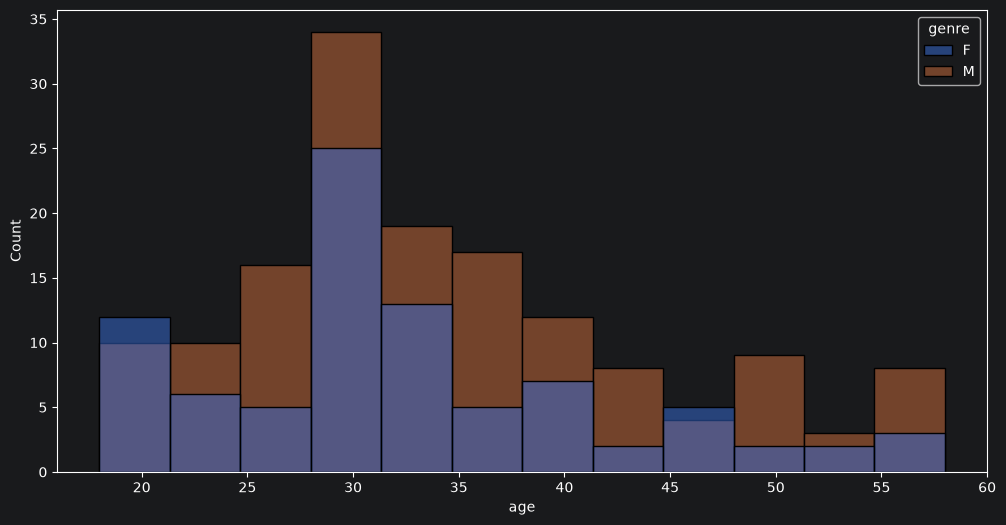

In [183]:
plt.figure(figsize=(12, 6))
sns.histplot(data=resigned_employees, x='age', hue='genre')
plt.show()

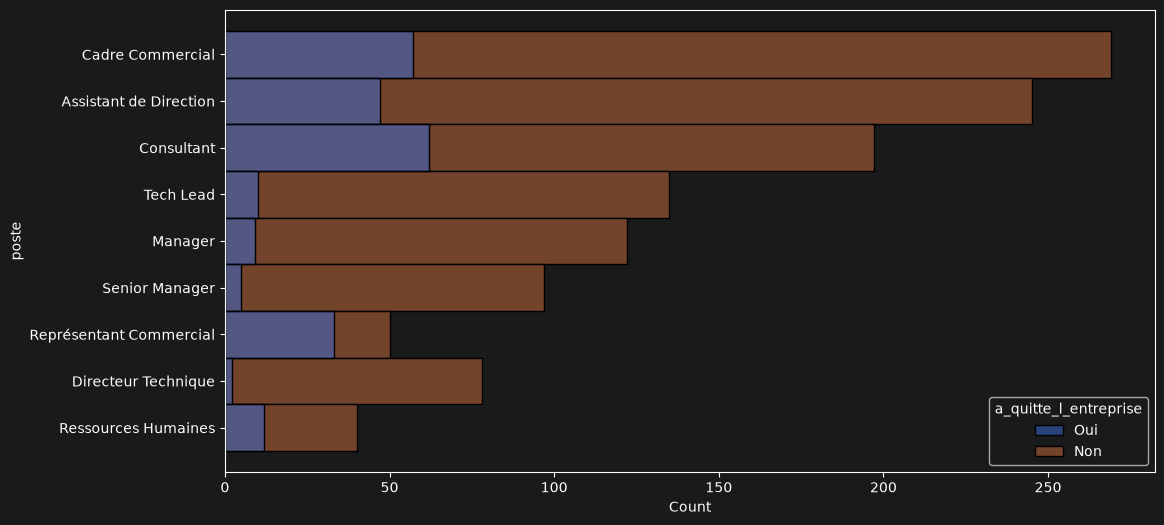

In [184]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, y='poste', hue='a_quitte_l_entreprise')
plt.show()

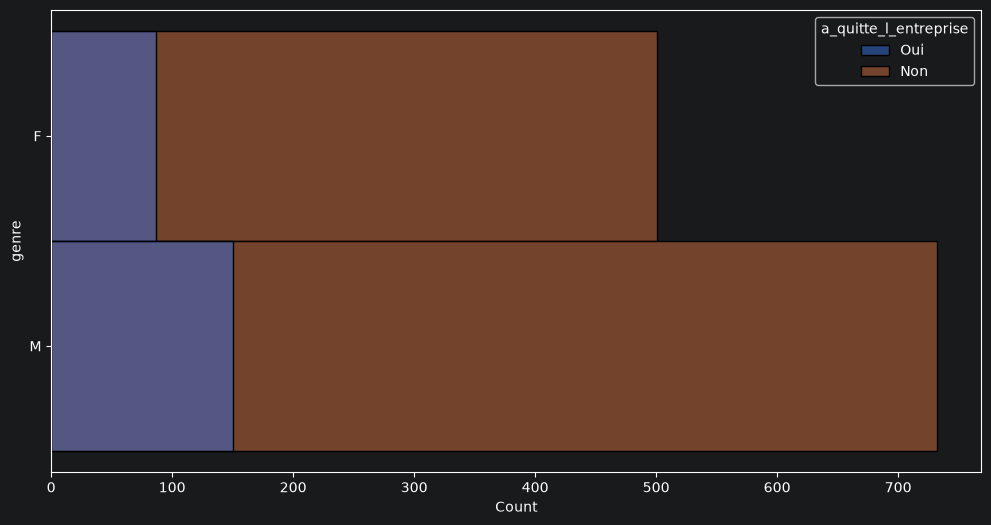

In [185]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, y='genre', hue='a_quitte_l_entreprise')
plt.show()

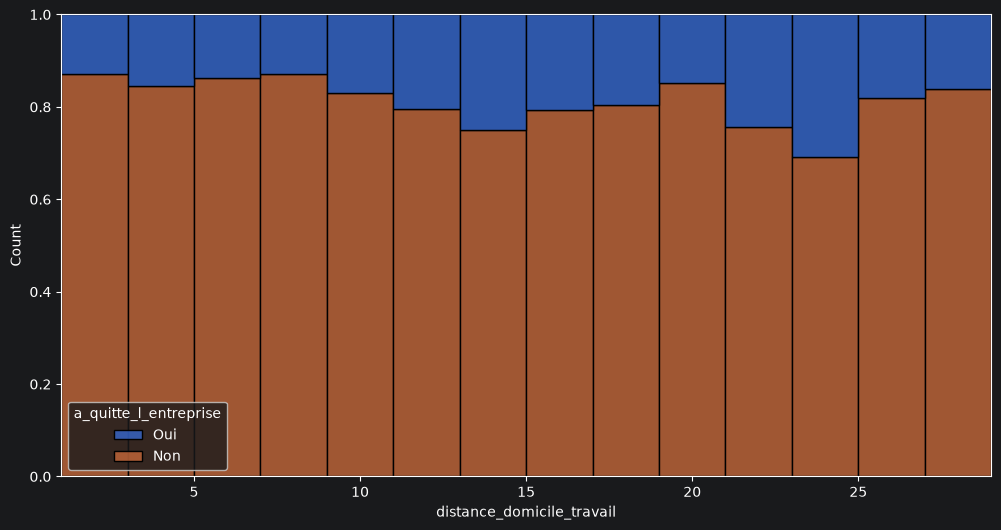

In [186]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=data,
    x='distance_domicile_travail',
    hue='a_quitte_l_entreprise',
    multiple='fill',  # Remplit les barres à 100% pour voir la proportion
)
plt.show()

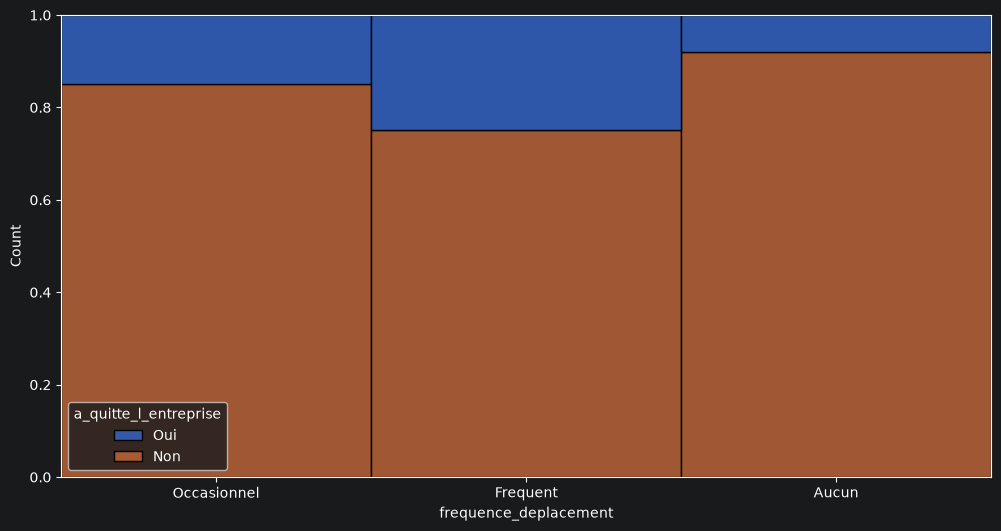

In [187]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=data,
    x='frequence_deplacement',
    hue='a_quitte_l_entreprise',
    multiple='fill',  # Remplit les barres à 100% pour voir la proportion
)
plt.show()

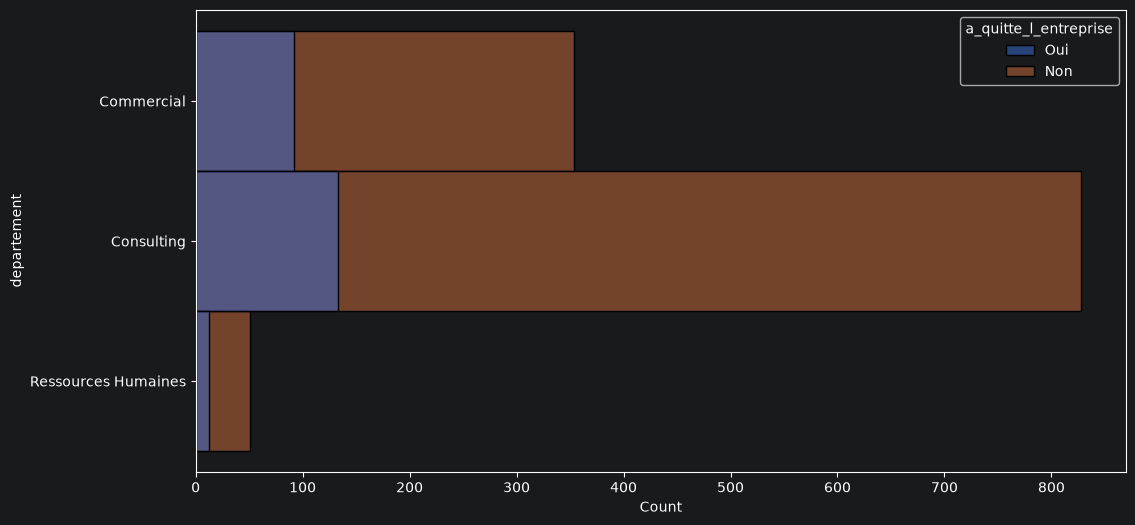

In [188]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, y='departement', hue='a_quitte_l_entreprise')
plt.show()

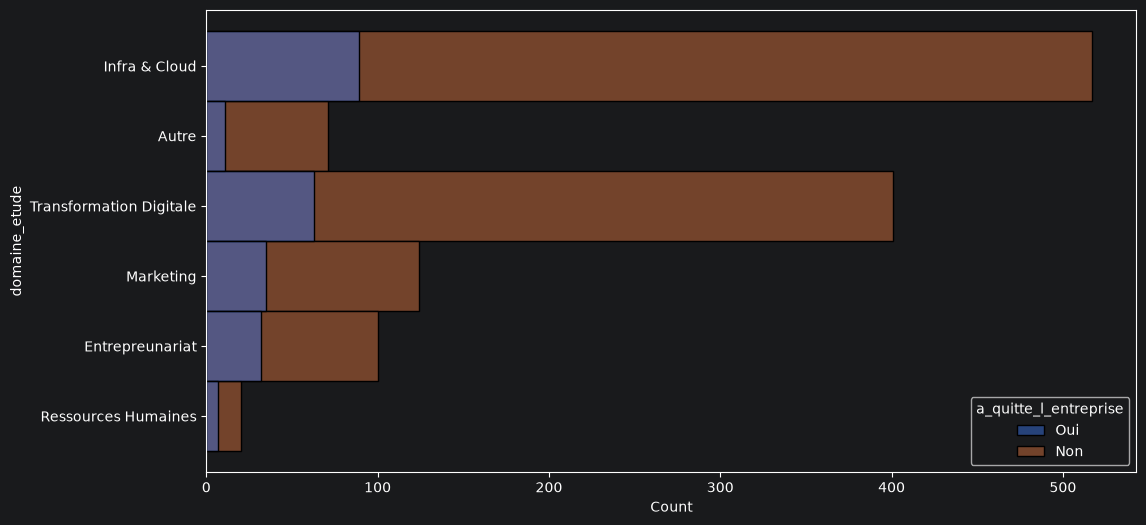

In [189]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, y='domaine_etude', hue='a_quitte_l_entreprise')
plt.show()

In [190]:
resigned_employees['nombre_experiences_precedentes'].describe()

count    237.000000
mean       2.940928
std        2.678519
min        0.000000
25%        1.000000
50%        1.000000
75%        5.000000
max        9.000000
Name: nombre_experiences_precedentes, dtype: float64

In [191]:
current_employees['nombre_experiences_precedentes'].describe()

count    1233.00000
mean        2.64558
std         2.46009
min         0.00000
25%         1.00000
50%         2.00000
75%         4.00000
max         9.00000
Name: nombre_experiences_precedentes, dtype: float64

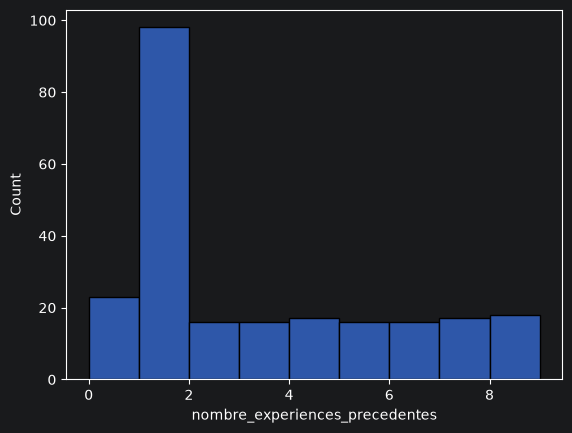

In [208]:
sns.histplot(data=resigned_employees, x='nombre_experiences_precedentes')
plt.show()

In [192]:
resigned_employees['annees_dans_l_entreprise'].describe()


count    237.000000
mean       5.130802
std        5.949984
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       40.000000
Name: annees_dans_l_entreprise, dtype: float64

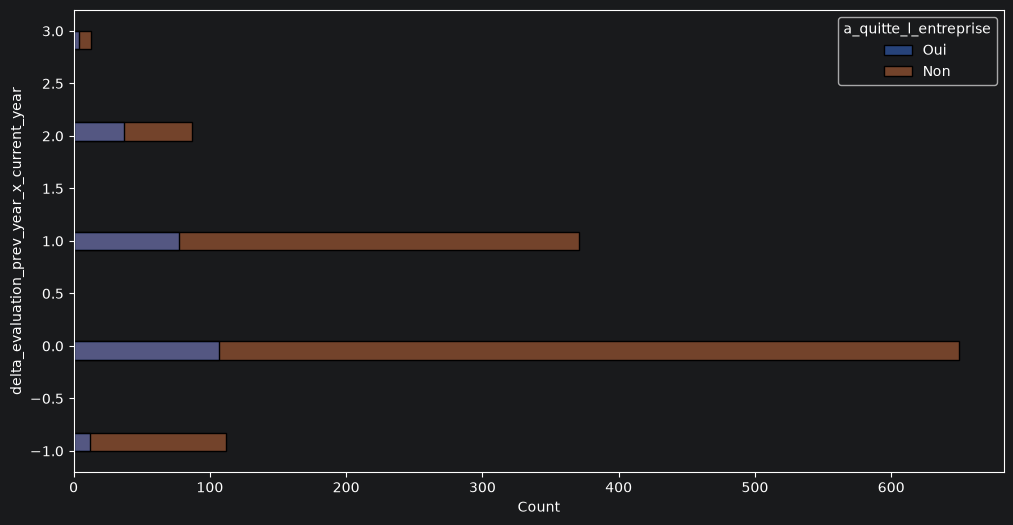

In [193]:
plt.figure(figsize=(12, 6))
data['delta_evaluation_prev_year_x_current_year'] = data['note_evaluation_actuelle'] - data['note_evaluation_precedente']
sns.histplot(data=data, y='delta_evaluation_prev_year_x_current_year', hue='a_quitte_l_entreprise')
plt.show()

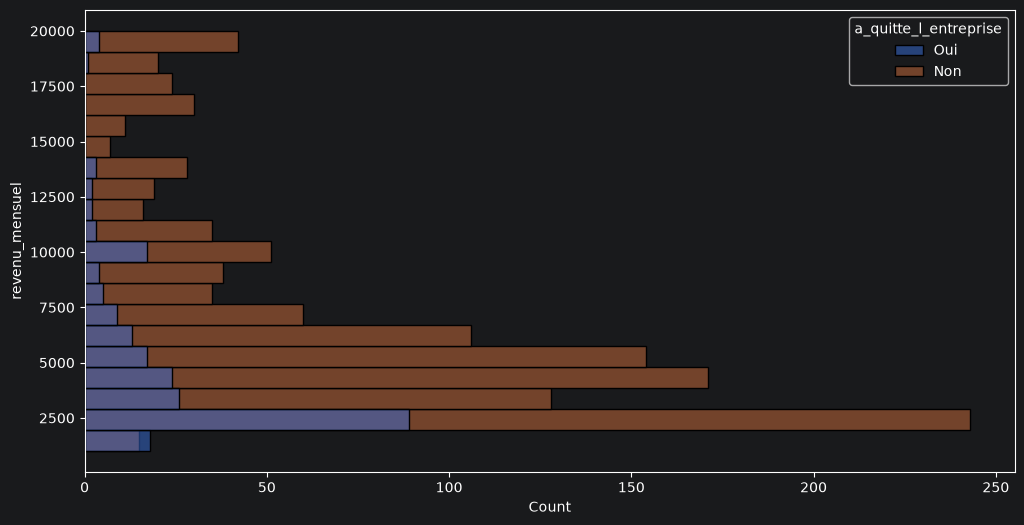

In [194]:
plt.figure(figsize=(12, 6))
sns.histplot(data=data, y='revenu_mensuel', hue='a_quitte_l_entreprise')
plt.show()

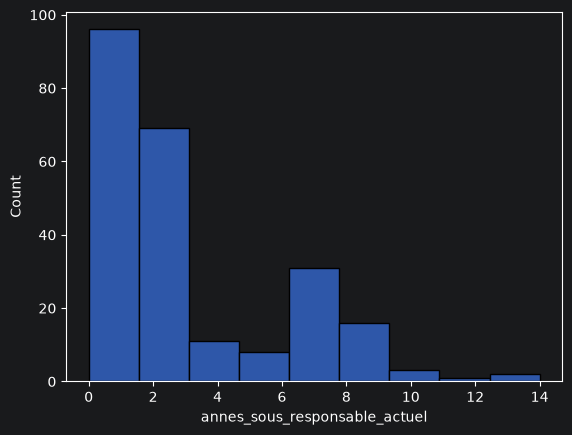

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [215]:
sns.histplot(resigned_employees, x='annes_sous_responsable_actuel')
plt.show()
plt.figure(figsize=(12, 6))